# Prognozowanie liczby wizyt na oddziale ratunkowym metodą wygładzania wykładniczego (PROC ESM)


## Podsumowanie zarządcze

Średniej wielkości system szpitalny potrzebuje rocznej prognozy miesięcznej liczby wizyt na oddziale ratunkowym (SOR), aby zaplanować obsadę pielęgniarską i pojemność łóżkową przed zimowym szczytem infekcji oddechowych. Ten notatnik buduje syntetyczny czteroletni miesięczny rejestr SOR (48 miesięcy, sty 2021 - gru 2024) i dopasowuje sezonowy model multiplikatywny Wintersa za pomocą **PROC ESM**, aby wyprodukować 12-miesięczną prognozę z 95-procentowymi przedziałami predykcji.

Dopasowany model dobrze oddaje szereg: w próbie **RMSE wynosi około 320 wizyt**, a **MAPE 4.16%**, więc typowy błąd miesięczny jest poniżej 5% wolumenu. Prognoza rzutuje znajomy kształt sezonowy na 2025 rok - szczyt grudniowo-lutowy w pobliżu **7,300-7,800 wizyt/miesiąc** i późnoletni dołek w pobliżu **5,800-5,900** - z pasmami predykcji, które rozszerzają się wraz z wydłużeniem horyzontu. Te liczby oraz stojące za nimi wagi wygładzania są odczytane bezpośrednio z wynikowych zbiorów danych procedury poniżej.


## Źródła danych

| Zbiór danych | Wiersze | Ziarno | Zmienne kluczowe | Opis |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Jeden wiersz na miesiąc kalendarzowy, sty 2021 - gru 2024 | `month` (miesięczna data SAS), `ed_visits` (całkowita miesięczna liczba wizyt na SOR) | Syntetyczny miesięczny wolumen wizyt na oddziale ratunkowym dla średniej wielkości systemu szpitalnego. Generowany z rosnącym trendem wzrostu (~3% rocznie), multiplikatywnym cyklem sezonowym szczytującym w zimowym sezonie oddechowym (gru-lut) i opadającym późnym latem, plus szum log-normalny, tak że amplituda sezonowa skaluje się z rosnącym poziomem. |


# Prognozowanie liczby wizyt na oddziale ratunkowym za pomocą PROC ESM

Planiści pojemności muszą wiedzieć, ilu wizyt na SOR spodziewać się każdego miesiąca, aby móc układać grafiki pielęgniarek, utrzymywać łóżka elastyczne i przygotowywać zapasy oddechowe przed zimowym szczytem. Wolumen SOR to podręcznikowy sezonowy szereg czasowy: rośnie powoli rok do roku, szczytuje w sezonie oddechowym grudzień-luty i opada późnym latem, a rozmiar sezonowego wahania rośnie wraz ze wzrostem poziomu bazowego. Ta multiplikatywna struktura sezonowa to dokładnie to, co ma uchwycić metoda multiplikatywna Wintersa w **PROC ESM**.

W tym notatniku:

1. Generujemy realistyczny czteroletni miesięczny rejestr SOR z trendem, multiplikatywną sezonowością i szumem.
2. Wizualizujemy szereg, aby potwierdzić jego multiplikatywną strukturę sezonową.
3. Dopasowujemy multiplikatywny model Wintersa za pomocą PROC ESM i odczytujemy jego wagi wygładzania oraz statystyki dopasowania z wynikowych zbiorów danych.
4. Produkujemy prognozę na 12 miesięcy do przodu z 95-procentowymi przedziałami predykcji i interpretujemy implikacje operacyjne.

## Krok 1 - Generowanie syntetycznego miesięcznego rejestru SOR

Budujemy 48 miesięcznych obserwacji od stycznia 2021 do grudnia 2024. Oczekiwany wolumen każdego miesiąca to poziom bazowy rosnący około 3% rocznie, pomnożony przez indeks sezonowy (najwyższy w środku zimy, najniższy późnym latem), a następnie zaburzony szumem log-normalnym, tak że zmienność losowa skaluje się z poziomem. `intnx` przesuwa datę wyrównaną do miesiąca o jeden okres na wiersz, a `streaminit` czyni losowanie odtwarzalnym.

In [1]:
DANE ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    TABLICA seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    POWTÓRZ i = 1 TO 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ month ed_visits;
WYKONAJ;

PROCEDURA DRUKUJ DANE=ed_census(obs=14) noobs ETYKIETA;
    ETYKIETA month = 'Miesiąc' ed_visits = 'Wizyty SOR';
    TYTUŁ 'Pierwsze 14 miesięcy syntetycznej liczby wizyt na SOR';
WYKONAJ;


                                 Pierwsze 14 miesięcy syntetycznej liczby wizyt na SOR                                  

 Miesiąc  Wizyty SOR
  202101        7103
  202102        6835
  202103        6668
  202104        5611
  202105        5816
  202106        5383
  202107        5586
  202108        5283
  202109        5161
  202110        6109
  202111        6451
  202112        6730
  202201        6847
  202202        7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Pierwsze miesiące potwierdzają założenia: wolumen otwiera się w pobliżu 7,100 w szczycie ze stycznia 2021, opada przez wiosnę i lato do dołka sierpniowo-wrześniowego, po czym wspina się z powrotem w kolejną zimę. Do stycznia 2022 szczyt podniósł się do około 6,800-7,200, odzwierciedlając ~3% roczny wzrost nałożony na cykl sezonowy.

## Krok 2 - Wizualizacja szeregu

Przed modelowaniem wykreślamy surowy szereg, aby potwierdzić spodziewaną strukturę: łagodny trend wzrostowy z powtarzającym się corocznym szczytem każdej zimy, którego amplituda poszerza się w czasie. Poszerzające się wahanie sezonowe to sygnatura *multiplikatywnego* procesu sezonowego i mówi nam, który model ESM wybrać.

                                 Pierwsze 14 miesięcy syntetycznej liczby wizyt na SOR                                  




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


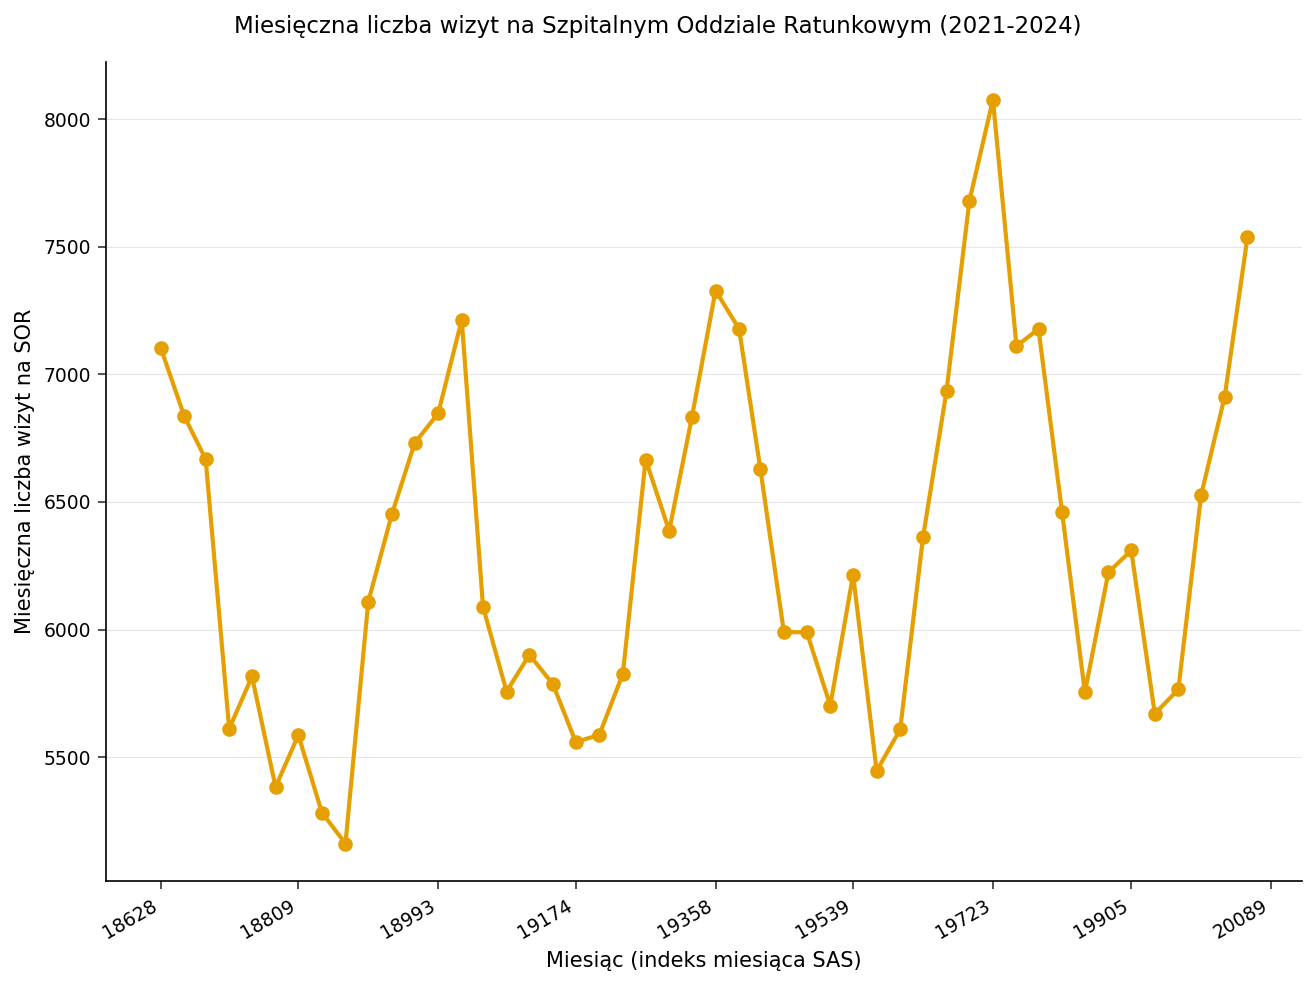

In [2]:
PROCEDURA SGPLOT DANE=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ETYKIETA='Miesiąc (indeks miesiąca SAS)';
    YAXIS ETYKIETA='Miesięczna liczba wizyt na SOR' grid;
    TYTUŁ 'Miesięczna liczba wizyt na Szpitalnym Oddziale Ratunkowym (2021-2024)';
WYKONAJ;


Wykres pokazuje cztery czyste cykle roczne. Każdy zimowy szczyt leży nieco wyżej niż poprzedni, wspinając się z około 7,100 w 2021 do mniej więcej 8,100 w szczycie 2024, podczas gdy letnie dołki rosną skromniej - wahanie sezonowe rośnie z poziomem. Ta poszerzająca się amplituda to znak rozpoznawczy multiplikatywnej sezonowości i uzasadnia `MODEL=WINTERS` (multiplikatywny Wintersa) w kolejnym kroku.

## Krok 3 - Dopasowanie multiplikatywnego modelu Wintersa

Dopasowujemy multiplikatywne sezonowe wygładzanie Wintersa na pełnej 48-miesięcznej historii. Instrukcja `ID` deklaruje `month` jako indeks czasu w interwale `MONTH`, a instrukcja `FORECAST` żąda `MODEL=WINTERS` z `LEAD=12`, aby rzutować rok do przodu. Przechwytujemy trzy wynikowe zbiory danych:

- `OUT=` - szereg historyczny z dołączoną prognozą (jedna kolumna `ed_visits`), z indeksem czasu rozszerzonym na horyzont prognozy - idealny do wykresów.
- `OUTFOR=` - składowe prognozy dla każdego okresu: prognoza punktowa (`PREDICT`) oraz dolna/górna granica predykcji.
- `OUTSUM=` - statystyki dopasowania modelu (RMSE, MAE, MAPE, AIC) i wagi wygładzania, w pojedynczym wierszu podsumowania.

`ALPHA=0.05` daje 95-procentowe granice predykcji, odpowiednie dla marginesów ryzyka w planowaniu pojemności. `PRINT=(STATISTICS)` wypisuje statystyki dopasowania i wagi wygładzania do listingu.

In [3]:
PROCEDURA esm DANE=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        DRUKUJ=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
WYKONAJ;

PROCEDURA DRUKUJ DANE=esm_summary noobs ETYKIETA;
    ETYKIETA rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Poziom (alfa)' beta='Trend (beta)' gamma='Sezonowość (gamma)';
    ZMIENNA rmse mae mape ALPHA beta gamma;
    TYTUŁ 'Statystyki dopasowania Wintersa i wagi wygładzania';
WYKONAJ;


                                 Pierwsze 14 miesięcy syntetycznej liczby wizyt na SOR                                  


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                   Statystyki dopasowania Wintersa i wagi wygładzania                                   

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


Wiersz `OUTSUM=` i wydrukowane statystyki są zgodne: multiplikatywne dopasowanie Wintersa osiąga w próbie **RMSE 320.4 wizyty**, **MAE 264.4** oraz **MAPE 4.16%** - typowy błąd miesięczny znacznie poniżej 5% wolumenu, co jest komfortowo dokładne dla planowania obsady. Wagi wygładzania to **alpha = 0.30** (poziom), **beta = 0.10** (trend) i **gamma = 0.10** (sezon). Umiarkowana waga poziomu pozwala poziomowi bazowemu dryfować w górę wraz ze wzrostem populacji pacjentów, podczas gdy małe wagi trendu i sezonu odzwierciedlają to, że tempo wzrostu i kształt zimowego szczytu są stabilne rok do roku i nie należy na nie nadmiernie reagować z miesiąca na miesiąc.

> Uwaga: są to statystyki dopasowania *w próbie* obliczone na próbie estymacyjnej, a nie na wydzielonym zbiorze poza próbą. Kwantyfikują, jak blisko model śledzi historię, na której go dopasowano.

## Krok 4 - Złożenie i stabelaryzowanie prognozy 12-miesięcznej

Zbiór `OUTFOR=` przechowuje prognozę punktową i granice predykcji dla każdego okresu, podczas gdy zbiór `OUT=` niesie indeks czasu czysto rozszerzony na horyzont prognozy. Wyrównujemy oba według kolejności obserwacji, aby dołączyć daty prognozy do granic predykcji, a następnie zostawiamy tylko 12 miesięcy prognozy. To są liczby, na których podstawie działałaby komisja ds. obsady.

In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
DANE out_idx;
    USTAW ed_with_forecast;
    row = _n_;
    PRZEMIANUJ month = fdate ed_visits = series_value;
WYKONAJ;

DANE for_idx;
    USTAW esm_forecast;
    row = _n_;
    PRZEMIANUJ ed_visits = observed;
    ZACHOWAJ row observed predict LOWER UPPER;
WYKONAJ;

DANE forecast_path;
    POŁĄCZ out_idx for_idx;
    WEDŁUG row;
    format fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
WYKONAJ;

DANE forecast_horizon;
    USTAW forecast_path;
    GDZIE observed = .;   /* forecast months only (no observed value) */
    ZACHOWAJ fdate predict LOWER UPPER;
WYKONAJ;

PROCEDURA DRUKUJ DANE=forecast_horizon noobs ETYKIETA;
    ETYKIETA fdate   = 'Miesiąc'
          predict = 'Prognozowane wizyty'
          LOWER   = 'Dolna granica 95%'
          UPPER   = 'Górna granica 95%';
    TYTUŁ 'Prognoza wizyt na SOR na 12 miesięcy z 95% granicami predykcji';
WYKONAJ;


                             Prognoza wizyt na SOR na 12 miesięcy z 95% granicami predykcji                             

 Miesiąc  Prognozowane wizyty  Dolna granica 95%   Górna granica 95%
  202501                7,822              7,194               8,450
  202502                7,539              6,651               8,427
  202503                7,292              6,204               8,380
  202504                6,263              5,007               7,519
  202505                6,397              4,992               7,801
  202506                6,039              4,501               7,578
  202507                6,236              4,574               7,897
  202508                5,867              4,091               7,644
  202509                5,802              3,918               7,686
  202510                6,804              4,818               8,790
  202511                7,173              5,090               9,256
  202512                7,567              5,391  


NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Prognoza niesie sezonową sygnaturę do przodu w rok 2025. Model rzutuje szczyt ze stycznia 2025 na około **7,822 wizyty** (przedział 95% 7,194-8,450), łagodnieje przez wiosnę, osiąga dno w późnoletnim dołku w pobliżu **5,802** we wrześniu (przedział 3,918-7,686), po czym odbudowuje się do grudniowego szczytu w wysokości mniej więcej **7,567** (przedział 5,391-9,742). Pasmo predykcji poszerza się stale wraz z horyzontem - przedział dla przyszłego miesiąca obejmuje około +/-630 wizyt, a dla przyszłego grudnia ponad +/-2,000 - bezpośrednie przypomnienie, że plany krótkoterminowe są znacznie pewniejsze niż te na koniec roku.

## Krok 5 - Wykres historii wraz z prognozą

Na koniec nakładamy prognozę na obserwowaną historię, aby planiści widzieli rzutowany zimowy szczyt i poszerzające się pasmo niepewności wraz z wydłużeniem horyzontu. Dzielimy wyrównany szereg `forecast_path` na historię **obserwowaną** (linia ciągła) i **prognozę 12-miesięczną** (linia przerywana), aby przejście było czytelne, i rysujemy pod spodem 95-procentowe pasmo predykcji. Oś X to miesięczny indeks daty SAS, biegnący od lewej do prawej od sty 2021 do gru 2025.

                             Prognoza wizyt na SOR na 12 miesięcy z 95% granicami predykcji                             




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


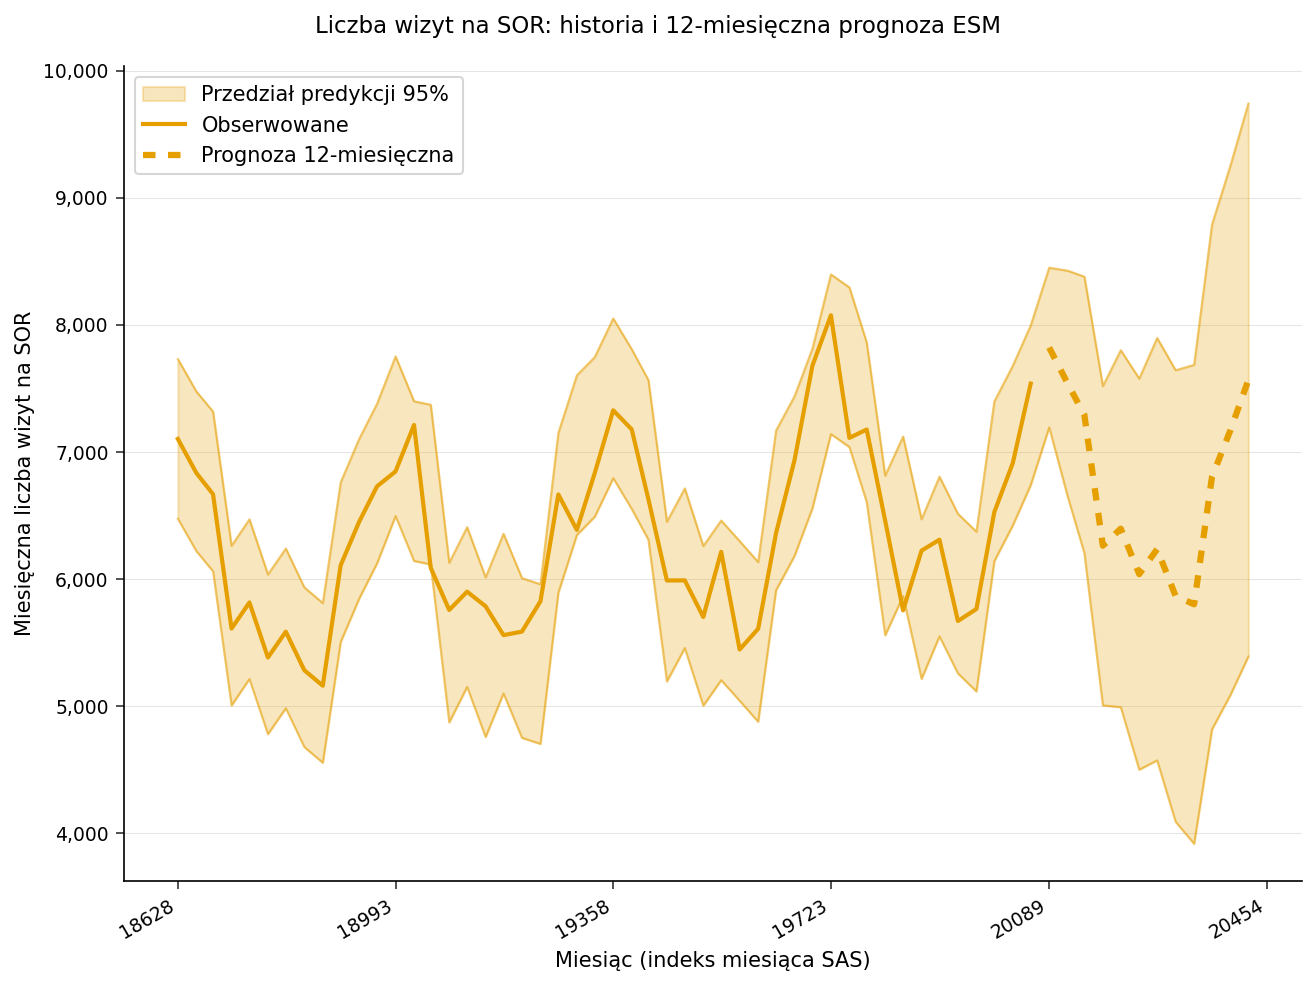

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
DANE forecast_plot;
    USTAW forecast_path;
    JEŚLI observed = . WTEDY fc_only = predict;   /* future months only */
    PRZECIWNIE fc_only = .;
WYKONAJ;

PROCEDURA SGPLOT DANE=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='Przedział predykcji 95%' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Obserwowane';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='Prognoza 12-miesięczna';
    XAXIS ETYKIETA='Miesiąc (indeks miesiąca SAS)';
    YAXIS ETYKIETA='Miesięczna liczba wizyt na SOR' grid;
    TYTUŁ 'Liczba wizyt na SOR: historia i 12-miesięczna prognoza ESM';
WYKONAJ;


## Interpretacja wyników

Multiplikatywny model Wintersa rozkłada wolumen SOR na powoli rosnący **poziom**, niemal płaski **trend** i stabilny wzorzec **sezonowy**. Wagi wygładzania odczytane z `OUTSUM=` opowiadają tę historię: umiarkowana waga poziomu (alpha = 0.30) pozwala poziomowi bazowemu dryfować w górę wraz ze wzrostem populacji pacjentów, podczas gdy małe wagi trendu i sezonu (beta = gamma = 0.10) odzwierciedlają to, że tempo wzrostu i kształt zimowego szczytu są wysoce stabilne rok do roku i nie należy na nie nadmiernie reagować z miesiąca na miesiąc.

**Statystyki dopasowania** potwierdzają, że model dobrze śledzi historię: RMSE około 320 wizyt i MAPE 4.16% oznaczają, że typowy błąd miesięczny jest poniżej 5% wolumenu. Operacyjnie **tabela prognozy i wykres pasma** kwantyfikują szczyt grudniowo-lutowy, pod który SOR powinien się obsadzić - mniej więcej 7,300-7,800 wizyt w miesiącach zimowych - a 95-procentowe granice predykcji definiują rozważny zakres pojemności: planuj obsadę podstawową pod prognozę punktową, a pokrycie elastyczne i łóżka szczytowe przygotuj z wyprzedzeniem w kierunku górnej granicy. Przedział poszerza się wraz z horyzontem, więc plan na przyszły miesiąc jest znacznie pewniejszy niż na przyszły grudzień i powinien być odświeżany w miarę napływu nowych danych rzeczywistych.

**Rozszerzenia:** porównaj `MODEL=ADDWINTERS` (sezonowość addytywna) z dopasowaniem multiplikatywnym, aby potwierdzić wybór multiplikatywny; zastosuj `TRANSFORM=LOG`, aby wymusić dodatniość i ustabilizować wariancję; lub dodaj instrukcję `BY`, aby prognozować wiele placówek szpitalnych w jednym wywołaniu PROC ESM.